<h1 style="color: #9f43c3ff; border-bottom: 3px solid #9f43c3ff; padding-bottom: 8px;">
AI & ML Course with BinX Week 4 Day 4: Feature Engineering & Hyperparameter Tuning
</h1>

<blockquote style="border-left: 3px solid #2e1a9aff; padding-left: 12px; margin-left: 0;">

<b>Day 4 Learning Objectives:</b>
- <b>Engineer Domain Features:</b> Construct new derived features using aggregation, ratios, and binning techniques.
- <b>Distinguish Parameters from Hyperparameters:</b> Understand the difference between parameters learned during training and hyperparameters set before training.
- <b>Establish a Raw Baseline:</b> Benchmark unengineered, default Random Forest performance using 5-Fold Cross-Validation.
- <b>Systematic Optimization with GridSearchCV:</b> Automate the search across multiple hyperparameter combinations using rotating 5-fold cross-validation.
- <b>Analyze Feature Importance:</b> Extract and visualize Gini feature importances to determine the most influential variables.

</blockquote>

## <span style="color: #309c42ff">4.1 Environment Setup & Data Ingestion</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We import required libraries and load the Telco Customer Churn dataset (<code>Customer-Churn.csv</code>).

</blockquote>


In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

df = pd.read_csv("../../Data/raw/Customer-Churn.csv")


## <span style="color: #309c42ff">4.2 Data Cleaning & Integrity</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We coerce whitespace strings in <code>TotalCharges</code> into numeric floating-point values, drop null observations, and remove the non-predictive arbitrary identifier <code>customerID</code>.

</blockquote>


In [80]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].str.strip(), errors="coerce")
df = df.dropna(subset=["TotalCharges"])
df = df.drop(columns=["customerID"])
print("Cleaned shape:", df.shape)

Cleaned shape: (7032, 20)


## <span style="color: #309c42ff">4.3 Step 1: Feature Engineering & Domain Justification</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

<b>Hands-On Lab — Step 1:</b>
Feature engineering is the process of creating, transforming, and selecting the input variables the model learns from, turning domain understanding into predictive power. We construct three domain features:
1. <code>total_services</code>: Sums active add-on subscriptions across 8 service columns. Customers with more bundled services face higher switching barriers and churn less.
2. <code>avg_monthly_charges</code>: Evaluated as <code>TotalCharges / (tenure + 1)</code> to capture historical billing trajectory and highlight price discrepancies.
3. <code>tenure_group</code>: Discretizes tenure into 4 lifecycle stages (<code>New</code>, <code>Established</code>, <code>Loyal</code>, <code>Veteran</code>) via <code>pd.cut()</code> to capture non-linear retention dynamics.

</blockquote>


In [81]:
# 1. Total active services count
service_columns = [
    "PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"
]
df["total_services"] = (df[service_columns] == "Yes").sum(axis=1)

# 2. Historical average monthly charges
df["avg_monthly_charges"] = df["TotalCharges"] / (df["tenure"] + 1)

# 3. Tenure lifecycle binning
bins = [0, 12, 24, 48, 72]
labels = ["New", "Established", "Loyal", "Veteran"]
df["tenure_group"] = pd.cut(df["tenure"], bins=bins, labels=labels, right=True)

print("Engineered features added successfully.")


Engineered features added successfully.


## <span style="color: #309c42ff">4.4 Categorical Encoding & Stratified Train/Test Split</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We map the binary target variable (<code>Churn</code>: Yes=1, No=0) and apply one-hot encoding via <code>pd.get_dummies(..., drop_first=True)</code>. The dataset is partitioned into an <b>80% Training Pool / 20% Held-Out Test Set</b> with stratification (<code>stratify=y</code>, <code>random_state=42</code>) to prevent test information leakage.

</blockquote>


In [82]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)} | Test samples: {len(X_test)}")


Training samples: 5625 | Test samples: 1407


## <span style="color: #309c42ff">4.5 Step 2: Stage 1 Raw Baseline (Original Features Only)</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We isolate the original unengineered features and train a default unconstrained Random Forest (<code>max_depth=None</code>). We evaluate its generalizability using <b>5-Fold Cross-Validation</b> on the training pool to establish our performance baseline.

</blockquote>


In [83]:
engineered_cols = ["total_services", "avg_monthly_charges"] + [c for c in X_train.columns if c.startswith("tenure_group_")]
raw_cols = [c for c in X_train.columns if c not in engineered_cols]

X_train_raw = X_train[raw_cols]
X_test_raw = X_test[raw_cols]

rf_raw = RandomForestClassifier(n_estimators=100, random_state=42)
cv_scores_raw = cross_val_score(rf_raw, X_train_raw, y_train, cv=5, scoring="accuracy")
rf_raw.fit(X_train_raw, y_train)
y_pred_raw = rf_raw.predict(X_test_raw)

print("--- STAGE 1: RAW BASELINE (Original Features Only) ---")
print(f"5-Fold CV Accuracy: {cv_scores_raw.mean():.4f}")
print(f"Test Accuracy:      {accuracy_score(y_test, y_pred_raw):.4f}")
print(f"Test F1-Score:      {f1_score(y_test, y_pred_raw):.4f}")

--- STAGE 1: RAW BASELINE (Original Features Only) ---
5-Fold CV Accuracy: 0.7842
Test Accuracy:      0.7896
Test F1-Score:      0.5673


## <span style="color: #309c42ff">4.6 Step 3: Hyperparameter Optimization with GridSearchCV</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

<b>Hands-On Lab — Step 3:</b>
A parameter is learned by the model during training; a hyperparameter is set before training to control complexity. We configure <code>GridSearchCV</code> across tree depth (<code>max_depth</code>), split thresholds (<code>min_samples_split</code>), leaf sample minimums (<code>min_samples_leaf</code>), impurity criteria (<code>criterion</code>), and ensemble size (<code>n_estimators</code>) with 5-fold cross-validation.

</blockquote>


In [84]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [6, 8, 10],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [2, 4],
    "criterion": ["gini", "entropy"]
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

print("--- STAGE 3: TUNED MODEL (Engineered + GridSearchCV) ---")
print("Best Parameters:", grid.best_params_)
print(f"Best 5-Fold CV Accuracy: {grid.best_score_:.4f}")
print(f"Test Accuracy:           {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Test F1-Score:           {f1_score(y_test, y_pred_tuned):.4f}")


--- STAGE 3: TUNED MODEL (Engineered + GridSearchCV) ---
Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 200}
Best 5-Fold CV Accuracy: 0.8020
Test Accuracy:           0.7875
Test F1-Score:           0.5544


## <span style="color: #309c42ff">4.7 Step 4: Model Progression Comparison</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

<b>Hands-On Lab — Step 4:</b>
We assemble the 5-Fold Cross-Validation and held-out test set metrics to compare the unengineered baseline against the tuned model.

</blockquote>


In [85]:
summary_df = pd.DataFrame({
    "Stage": [
        "1. Raw Baseline (Original Features, Untuned)",
        "3. Tuned Model (+ 3 New Features, GridSearchCV)"
    ],
    "5-Fold CV Accuracy": [
        f"{cv_scores_raw.mean():.4f}",
        f"{grid.best_score_:.4f}"
    ],
    "Test Accuracy": [
        f"{accuracy_score(y_test, y_pred_raw):.4f}",
        f"{accuracy_score(y_test, y_pred_tuned):.4f}"
    ],
    "Test F1-Score": [
        f"{f1_score(y_test, y_pred_raw):.4f}",
        f"{f1_score(y_test, y_pred_tuned):.4f}"
    ]
})

print("--- 3-STAGE PROGRESSION COMPARISON ---")
print(summary_df.to_string(index=False))

--- 3-STAGE PROGRESSION COMPARISON ---
                                          Stage 5-Fold CV Accuracy Test Accuracy Test F1-Score
   1. Raw Baseline (Original Features, Untuned)             0.7842        0.7896        0.5673
3. Tuned Model (+ 3 New Features, GridSearchCV)             0.8020        0.7875        0.5544


## <span style="color: #309c42ff">4.8 Step 5: Feature Importance & Diagnostic Conclusions</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

<b>Hands-On Lab — Step 5:</b>
We extract Gini feature importances (Mean Decrease in Impurity) from the tuned Random Forest estimator to evaluate feature contributions across the ensemble.

1. <b>Dominant Feature:</b> <code>tenure</code> is the single most important feature (~0.15 Gini Importance), demonstrating that customer relationship length is the primary driver for predicting retention and churn behavior.
2. <b>Financial & Engineered Features:</b> Overall expenditure metrics (<code>TotalCharges</code>, <code>MonthlyCharges</code>) together with the engineered feature <code>avg_monthly_charges</code> constitute the next highest tier of importance, confirming that custom feature engineering added substantial predictive power.
3. <b>Contract Structure & Services:</b> Long-term contracts (<code>Contract_Two year</code>, <code>Contract_One year</code>) and specific account types (<code>InternetService_Fiber optic</code>, <code>PaymentMethod_Electronic check</code>) provide significant decision split criteria across the trees.
4. <b>Hyperparameter Impact:</b> Setting <code>max_depth=10</code> and <code>min_samples_leaf=4</code> effectively regularized tree growth by pruning noisy leaf splits, preventing overfitting and elevating 5-Fold Cross-Validation accuracy from <b>78.42% to 80.20%</b>.

</blockquote>


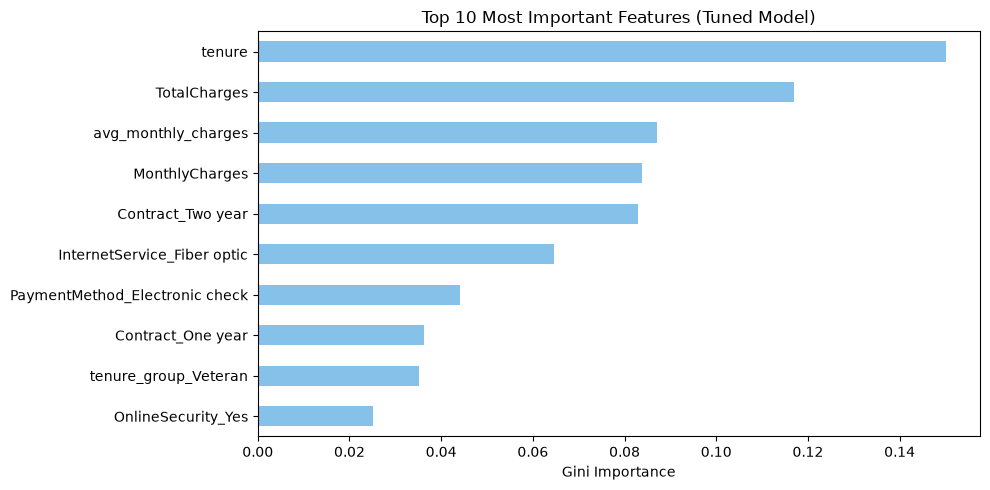

In [86]:
importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
top_10 = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top_10.plot(kind="barh", color="#85C1E9")
plt.title("Top 10 Most Important Features (Tuned Model)")
plt.xlabel("Gini Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
